<a href="https://colab.research.google.com/github/LunaGar1/Pratica2-Vision-e-IA/blob/main/P2_reto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto 2: Clasificación deflores parte 2

In [ ]:
from urllib.request import urlretrieve
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, ConfusionMatrixDisplay, classification_report

In [ ]:
irisURL = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
urlretrieve(irisURL)
df_iris = pd.read_csv(irisURL, sep=',', names=["Largo_Sepalo", "Ancho_Sepalo", "Largo_Petalo", "Ancho_Petalo", "Clase"])
df_iris = df_iris.dropna()

In [ ]:
print(df_iris)
print(df_iris.head())
print(df_iris.tail())

     Largo_Sepalo  Ancho_Sepalo  Largo_Petalo  Ancho_Petalo           Clase
0             5.1           3.5           1.4           0.2     Iris-setosa
1             4.9           3.0           1.4           0.2     Iris-setosa
2             4.7           3.2           1.3           0.2     Iris-setosa
3             4.6           3.1           1.5           0.2     Iris-setosa
4             5.0           3.6           1.4           0.2     Iris-setosa
..            ...           ...           ...           ...             ...
145           6.7           3.0           5.2           2.3  Iris-virginica
146           6.3           2.5           5.0           1.9  Iris-virginica
147           6.5           3.0           5.2           2.0  Iris-virginica
148           6.2           3.4           5.4           2.3  Iris-virginica
149           5.9           3.0           5.1           1.8  Iris-virginica

[150 rows x 5 columns]
   Largo_Sepalo  Ancho_Sepalo  Largo_Petalo  Ancho_Petalo       

## <span style="color:yellow">Bayes Ingenuos</span>

### Separar X, y, entrenamiento y pruebas

In [ ]:
X_bayes = df_iris.drop('Clase', axis=1).copy()
y_bayes = df_iris['Clase'].copy()

In [ ]:
X_train_bayes, X_test_bayes, y_train_bayes, y_test_bayes = train_test_split(X_bayes, y_bayes, test_size=0.3, random_state=28)

### Entrenar modelo logístico, predicciones

In [ ]:
modelo_bayes = GaussianNB()
modelo_bayes.fit(X_train_bayes, y_train_bayes)

GaussianNB()

In [ ]:
pred_bayes = modelo_bayes.predict(X_test_bayes)

print(pred_bayes)

['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor'
 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor'
 'Iris-setosa']


### Validaciones

In [ ]:
accuracy_bayes = accuracy_score(y_test_bayes, pred_bayes)
report = classification_report(y_test_bayes, pred_bayes)

print(f"Precision de Bayes Ingenuos: ", accuracy_bayes)
print(report)

Precision de Bayes Ingenuos:  0.9111111111111111
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       1.00      0.79      0.88        19
 Iris-virginica       0.78      1.00      0.88        14

       accuracy                           0.91        45
      macro avg       0.93      0.93      0.92        45
   weighted avg       0.93      0.91      0.91        45



In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_bayes, pred_bayes)

### Cambiar hiperparametros

In [ ]:
param_grid = {'var_smoothing': np.logspace(0, -12, num=100)}

grid = GridSearchCV(GaussianNB(), param_grid, cv=5, scoring='accuracy')

grid.fit(X_train_bayes, y_train_bayes)

print(f"Mejor valor de var_smoothing: {grid.best_params_['var_smoothing']} con precisión realista de: {grid.best_score_}")

Mejor valor de var_smoothing: 0.08111308307896872 con precisión realista de: 0.9619047619047618


## <span style="color:yellow">Maquinas de Soporte Vectorial</span>

In [ ]:
X_svm = df_iris.drop('Clase', axis=1).copy()
y_svm = df_iris['Clase'].copy()

In [ ]:
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(X_svm, y_svm, test_size=0.3, random_state=28)

### Entrenar modelo logístico, predicciones

In [ ]:
modelo_svm = SVC()
modelo_svm.fit(X_svm_train, y_svm_train)

SVC()

In [ ]:
pred_svm = modelo_svm.predict(X_svm_test)


### Validaciones

In [ ]:
accuracy_svm = accuracy_score(y_svm_test, pred_svm)
report = classification_report(y_svm_test, pred_svm)

print(f"Precision de SVM: ", accuracy_svm)
print(report)

Precision de SVM:  0.9555555555555556
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       1.00      0.89      0.94        19
 Iris-virginica       0.88      1.00      0.93        14

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



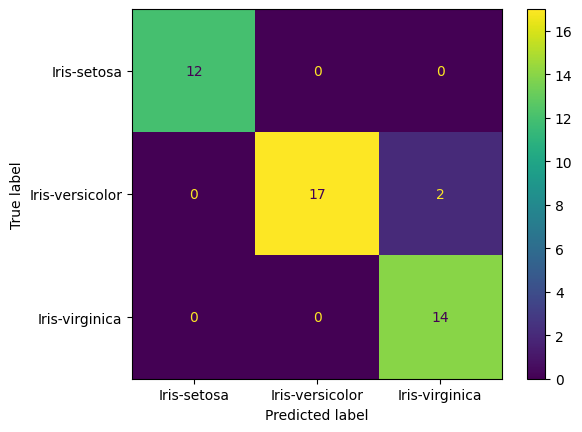

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_svm_test, pred_svm)

### Cambiar hiperparametros

In [ ]:
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly']
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='accuracy')

grid_svm.fit(X_svm_train, y_svm_train)

print(f"Mejores hiperparámetros: {grid_svm.best_params_} con precisión realista de: {grid_svm.best_score_}")

Mejores hiperparámetros: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'} con precisión realista de: 0.980952380952381


## <span style="color:red">Conclusiones</span>

<ul>
    <li>
        El modelo <strong>Bayes Ingenuo</strong> en su forma predeterminada alcanzó una precisión de ~91%, equivocandose en la predicción de 4 datos, exactamente, predijo mal la clase Versicolor afirmando que es un Virginica, por lo que podemos inferir que son Clases con características con valores más cercanos que la clase Setosa, como también se puede ver en el reporte de precision, recall y score.
    </li>
    <li>
        El hiperparametro a cambiar en <strong>Bayes Ingenuo</strong> es el "var_smoothing" que es un valor pequeño que se le suma a la varianza para evitar división por cero. Se utilizaron 100 numeros para entrenar varios modelos y encontrar el mejor valor para este hiperparametro, el cual fue 0.08... Con este valor se obtiene una precisión promedio de aproximadamente ~96%.
    </li>
    <li>
        El modelo <strong>Máquinas de Soporte Vectorial</strong> en su forma básica obtuvo una precisión de ~95% incluso sin modificar ningun parámetro, indicando que el dataset es relativamente fácil de separar. En estas condiciones, el modelo predice mal dos flores como Virginica que deberían ser Versicolor, reforzando así lo que ya habiamos visto en el modelo anterior, que la clase Setosa es más separable respecto a las otras, que las demás entre si.
    </li>
    <li>
        Para el modelo <strong>Máquinas de Soporte Vectorial</strong> los hiperparámetros que se pueden modificar son: La regularización C que controla el margen de error, entre más pequeño más margen y entre más grande más perfeccionista es. El kernel es para definir la frontera, se puede elegir "lineal" para una frontera lineal, "rbf" para una frontera no lineal, y "poly" para una polinomial. Y gamma para definir que tan suave o compleja es la frontera.
    </li>
    <li>
        Al modificar los hiperparámetros del modelo <strong>Máquinas de Soporte Vectorial</strong> obtenemos una precisión realista de ~98%, y para esto se debió usar C = 0.1, gamma = 0.1, y kernel = poly. Indicando que el dataset es casi linealmente separable pero si existe cierta superposición entre las clases Versicolor y Virginica, lo que se logra separar mejor con el kernel polinomial porque este permite una frontera ligeramente no lineal. El valor de C sugiere que el modelo generaliza mejor cuando no intenta ajustar perfectamente todo, es decir, cuando deja un margen más amplio; y el gamma es moderado evitando fronteras demasiado complejas o demasiado suaves.
    </li>
    <li>
        Sin cambiar los hiperparametros se podría decir que el modelo <strong>Máquinas de Soporte Vectorial</strong> da mejores resultados que el modelo <strong>Bayes Ingenuo</strong>, y al igual también se podría afirmar que sigue siendo superior incluso al entrenar los modelos con los mejores hiperparámetros.
    </li>
</ul>

## <span style="color:blue">Conclusiones</span>

*   **Bayes Ingenuo (Naive Bayes)**:
    *   Precisión inicial de ~91%, con errores en la clasificación de `Iris-versicolor` como `Iris-virginica`.
    *   Al optimizar el hiperparámetro `var_smoothing`, la precisión mejoró a ~96%.

*   **Máquinas de Soporte Vectorial (SVM)**:
    *   Precisión inicial de ~95% sin ajustes, superando a Bayes Ingenuo por defecto.
    *   También mostró errores clasificando `Iris-versicolor` como `Iris-virginica`, indicando una superposición entre estas clases.
    *   Con la optimización de hiperparámetros (`C=0.1`, `gamma=0.1`, `kernel='poly'`), la precisión alcanzó un ~98%, confirmando que un kernel polinomial ayuda a manejar la ligera no-linealidad.

*   **Comparación General**: El modelo SVM consistentemente superó a Bayes Ingenuo en precisión, tanto en su configuración predeterminada como después de la optimización de hiperparámetros. El dataset es casi linealmente separable, pero la distinción entre `Iris-versicolor` y `Iris-virginica` es la más desafiante para ambos modelos.